# Selenium이란?
* 웹브라우저를 자동으로 제어하는 라이브러리
* 원래 다양한 웹브라우저를 자동으로 테스트하는 도구
* 코드를 통해 웹브라우저 조작 가능
* 동적 웹사이트에서 정보를 가져오는데 활용

In [1]:
import requests
from bs4 import BeautifulSoup as bs
import os
import pandas as pd
import time
from sqlalchemy import create_engine
import pymysql
pymysql.install_as_MySQLdb()

In [4]:
import selenium
from selenium import webdriver
from selenium.webdriver.common.by import By
# 웹드라이버도 같이 설치해줘야함

In [148]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys


options = Options()
options.add_experimental_option("detach", True)
options.add_argument("start-maximized")
options.add_argument("Chrome/135.0.0.0")
options.add_argument("lang=ko_KR")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )
driver.get("https://search.shopping.naver.com/book/search?bookTabType=ALL&pageIndex=1&pageSize=40&prevQuery=%EB%84%A4%EC%9D%B4%EB%B2%84%20%EC%B1%85&query=%ED%8C%8C%EC%9D%B4%EC%8D%AC&sort=REL")

# selenium에서 원하는 요소 찾기
* driver.find_element(By.CSS_SELECTOR, css셀렉터):1개의 요소 찾기
* driver.find_elements (By.CSS_SELECTOR, css셀렉터) : 여러 개의 요소 찾기
* driver.find_element(By.ID,"id"): html에서 id 속성을 찾아줌
* driver.find_element(By.LINK_TEXT, "link에 포함된 문자") : link에 포함된 문자 찾기
* driver.find_element(By.PARTIAL_LINK_TEXT,"link에 포함된 일부 문자"): link에 포함된 일부 문자가 포함된 문자 찾기

In [17]:
driver.find_elements(By.CSS_SELECTOR,"div.bookListItem_title__1mWGq")

[<selenium.webdriver.remote.webelement.WebElement (session="3e3a49555b5d8749d81b8f7f146c5f88", element="f.0100FE5348F33BF4A74C23AD86F4F48D.d.3622792FB9CB78A92FE4BE658CEAD423.e.234")>,
 <selenium.webdriver.remote.webelement.WebElement (session="3e3a49555b5d8749d81b8f7f146c5f88", element="f.0100FE5348F33BF4A74C23AD86F4F48D.d.3622792FB9CB78A92FE4BE658CEAD423.e.760")>,
 <selenium.webdriver.remote.webelement.WebElement (session="3e3a49555b5d8749d81b8f7f146c5f88", element="f.0100FE5348F33BF4A74C23AD86F4F48D.d.3622792FB9CB78A92FE4BE658CEAD423.e.803")>,
 <selenium.webdriver.remote.webelement.WebElement (session="3e3a49555b5d8749d81b8f7f146c5f88", element="f.0100FE5348F33BF4A74C23AD86F4F48D.d.3622792FB9CB78A92FE4BE658CEAD423.e.848")>,
 <selenium.webdriver.remote.webelement.WebElement (session="3e3a49555b5d8749d81b8f7f146c5f88", element="f.0100FE5348F33BF4A74C23AD86F4F48D.d.3622792FB9CB78A92FE4BE658CEAD423.e.883")>,
 <selenium.webdriver.remote.webelement.WebElement (session="3e3a49555b5d8749d81b

In [22]:
for el in driver.find_elements(By.CSS_SELECTOR,"div.bookListItem_title__1mWGq"):
    print(el.get_attribute('outerHTML'))

<div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>혼자 만들면서 공부하는 파이썬</span><span> (37개 라이브러리와 API로 보고서, 차트, 게임, 맵, AI 챗봇 만들기|저자 직강 유튜브 강의, 오픈 채팅 제공)</span></span></div>
<div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>혼자 공부하는 파이썬</span><span> (1:1 과외하듯 배우는 프로그래밍 자습서)</span></span></div>
<div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>Do it! 점프 투 파이썬</span><span> (중학생도 첫날부터 실습하는 초고속 입문서)</span></span></div>
<div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>파이썬</span></span></div>
<div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>파이썬</span><span> (제2판)</span></span></div>
<div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>파이썬</span></span></div>
<div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>파이썬</span><span> (비전공자를위한 파이썬 기초 입문서)</span></span></div>
<d

In [29]:
driver.find_element(By.CSS_SELECTOR,".bookListItem_grade__e60mi").text

'평점5.0 (4)'

In [24]:
driver.find_element(By.CSS_SELECTOR,".bookListItem_item_inner__edK7P > a")

<selenium.webdriver.remote.webelement.WebElement (session="3e3a49555b5d8749d81b8f7f146c5f88", element="f.0100FE5348F33BF4A74C23AD86F4F48D.d.3622792FB9CB78A92FE4BE658CEAD423.e.229")>

In [28]:
# 마우스 스크롤링
driver.execute_script(f"window.scrollTo(0,1000)") #1000px 내림
driver.execute_script(f"window.scrollTo(0,2000)")

In [32]:
y=0
y_step=1000
for scroll_times in range(1,8):
    y+=y_step
    driver.execute_script(f"window.scrollTo(0,{y})")
    time.sleep(1)

'<html lang="ko"><head><meta charset="utf-8" data-next-head=""><meta name="viewport" content="width=device-width, initial-scale=1, shrink-to-fit=no, minimum-scale=1.0, maximum-scale=1.0, user-scalable=no, viewport-fit=cover" data-next-head=""><meta http-equiv="Cache-Control" content="no-cache, no-store, must-revalidate" data-next-head=""><title data-next-head="">파이썬 : 네이버 도서</title><link rel="shortcut icon" href="https://ssl.pstatic.net/shoppingsearch/static/book/book-250402-163053/img/favicon.ico" data-next-head=""><link rel="apple-touch-icon" href="https://ssl.pstatic.net/shoppingsearch/static/book/book-250402-163053/img/favicon_180.png" data-next-head=""><meta property="og:title" content="파이썬 : 네이버 도서" data-next-head=""><meta property="og:description" content="\'파이썬\'의 네이버 도서 검색 결과입니다." data-next-head=""><meta property="og:image" content="https://ssl.pstatic.net/shoppingsearch/static/icons/ogtag_shopping_book.png" data-next-head=""><meta property="og:url" content="https://search.sho
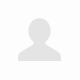
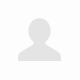

In [33]:
html_source=driver.page_source
html_source

In [35]:
soup=bs(html_source,'lxml')
soup.select("div.bookListItem_title__1mWGq")

[<div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>혼자 만들면서 공부하는 파이썬</span><span> (37개 라이브러리와 API로 보고서, 차트, 게임, 맵, AI 챗봇 만들기|저자 직강 유튜브 강의, 오픈 채팅 제공)</span></span></div>,
 <div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>혼자 공부하는 파이썬</span><span> (1:1 과외하듯 배우는 프로그래밍 자습서)</span></span></div>,
 <div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>Do it! 점프 투 파이썬</span><span> (중학생도 첫날부터 실습하는 초고속 입문서)</span></span></div>,
 <div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>파이썬</span></span></div>,
 <div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>파이썬</span><span> (제2판)</span></span></div>,
 <div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>파이썬</span></span></div>,
 <div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>파이썬</span><span> (비전공자를위한 파이썬 기초 입문서)</span></s

In [38]:
driver.find_element(By.ID,"book_list").get_attribute("innerHTML")

'<div class="bookSearchList_sort_area___A5Fp"><div class="sortFilterItem_sort_box__1_TGY"><a href="#" role="button" class="sortFilterItem_btn_basic_sort__WUOjl" data-shp-page-key="100388780" data-shp-nsc="shopping.book" data-shp-inventory="bok_sch" data-shp-area="bok_sch.sortopen" data-shp-area-type="action" data-shp-area-id="sortopen">네이버 랭킹순<svg xmlns="http://www.w3.org/2000/svg" width="12" height="7" class="sortFilterItem_svg_arrow__gurAO"><path fill="#7C8187" d="M6.056 5.047 10.78.444l.775.755-5.5 5.357-5.5-5.357.774-.755z"></path></svg></a><ul class="sortFilterItem_list_sort__KLVJK"><li class="sortFilterItem_item_sort__94YJE sortFilterItem_type_info__UkZU1 sortFilterItem_active__sl_G6"><a href="#" role="button" class="sortFilterItem_btn_sort__l6g3x _nlog_click _nlog_impression_element" data-shp-page-key="100388780" data-shp-nsc="shopping.book" data-shp-inventory="bok_sch" data-shp-area="bok_sch.sort" data-shp-area-type="slot" data-shp-area-id="sort" data-shp-contents-id="네이버 랭킹순" 

In [41]:
driver.find_element(By.PARTIAL_LINK_TEXT,"파이썬").get_attribute("innerHTML")

'<div class="bookListItem_thumbnail_area__W3MCC"><div class="bookListItem_thumbnail__ABXyE"><img src="https://shopping-phinf.pstatic.net/main_5285933/52859338841.20250209071357.jpg?type=w300" alt="혼자 만들면서 공부하는 파이썬"></div></div><div class="bookListItem_text_area__6gSV2"><div class="bookListItem_feature__Tck1v">컴퓨터/IT 103위</div><div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>혼자 만들면서 공부하는 파이썬</span><span> (37개 라이브러리와 API로 보고서, 차트, 게임, 맵, AI 챗봇 만들기|저자 직강 유튜브 강의, 오픈 채팅 제공)</span></span></div><div class="bookListItem_detail__VW1kD"><div class="bookListItem_define_item__jqcW8"><span class="bookListItem_define_title__W5Fg6">저자</span><span class="bookListItem_define_data__fu2A5">문현일</span></div><div class="bookListItem_define_item__jqcW8 bookListItem_publish__6XykH"><div class="bookListItem_detail_publish__SGgZN"><span class="bookListItem_define_title__W5Fg6">출판</span><span class="bookListItem_define_data__fu2A5">한빛미디어</span></div><div class="bookListItem_det

# 찾은 요소에서 요소의 속성값 출력하기
* find_element(By.CSS_SELECTOR,"css셀렉터").get_attribute("속성명")

In [43]:
seller_link = "#book_list > ul > li:nth-child(1) > div > div > div:nth-child(2) > a"

In [46]:
driver.find_element(By.CSS_SELECTOR,seller_link).get_attribute("class")

'bookListItem_item_box__TV98j linkAnchor _nlog_click _nlog_impression_element'

# 검색창을 찾아 검색어 입력하고 서치버튼 클릭하기
* 키보드 입력하기
    * driver.send_keys("검색창 입력 내용").send_keys("ENTER")
* 마우스 클릭하기
    * driver.click()

In [51]:
driver.find_element(By.CSS_SELECTOR,"._searchInput_search_text_83jy9._nlog_click").get_attribute("outerHTML")

'<input type="text" class="_searchInput_search_text_83jy9 _nlog_click" title="검색어 입력" placeholder="상품명 또는 브랜드 입력" maxlength="50" data-shp-page-key="100388780" data-shp-nsc="shopping.book" data-shp-inventory="GNB" data-shp-area="GNB.input" data-shp-area-type="action" data-shp-area-id="input" value="파이썬">'

In [60]:
search_box=driver.find_element(By.CSS_SELECTOR,"._searchInput_search_text_83jy9._nlog_click")
search_box.clear()
search_box.send_keys("파이썬")
#search_box.send_keys(Keys.ENTER)


In [61]:
search_button=driver.find_element(By.CSS_SELECTOR, "._searchInput_button_search_wu9xq._nlog_click")
search_button.click()

# 네이버 도서에서 책 검색해서 책 정보 가져오기
* 페이지 5까지 가져오기
* 마우스 스크롤 필수
<br>
<br>
* 책 제목
* 상세정보 링크
* 저자
* 출판사
* 출간일
* 평점
* 가격

In [63]:
url="https://search.shopping.naver.com/book/home"

In [74]:
options = Options()
options.add_experimental_option("detach", True)
options.add_argument("start-maximized")
options.add_argument("Chrome/135.0.0.0")
options.add_argument("lang=ko_KR")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )
driver.get(url)

In [75]:
search_box=driver.find_element(By.CSS_SELECTOR,"._searchInput_search_text_83jy9._nlog_click")
search_box.clear()
search_box.send_keys("파이썬")
search_box.send_keys(Keys.ENTER)

In [ ]:
y=0
y_step=1000
for scroll_times in range(1,8):
    y+=y_step
    driver.execute_script(f"window.scrollTo(0,{y})")
    time.sleep(1)

In [82]:
last_height = driver.execute_script("return document.body.scrollHeight")
while True:
    # Scroll down to bottom
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")

    # Wait to load page
    time.sleep(0.5)

    # Calculate new scroll height and compare with last scroll height
    new_height = driver.execute_script("return document.body.scrollHeight")
    if new_height == last_height:
        break
    last_height = new_height

# 웹페이지가 모두 로딩될 때 까지 기다리기
* from selenium.webdrive.support.ui import WebDreiverWait
* from selenium.webdrive.suppert import expected_conditions as EC

In [ ]:
# from selenium.webdrive.support.ui import WebDreiverWait
# from selenium.webdrive.suppert import expected_conditions as EC

# wait=WebDriverWait(driver,10)
# button=wait.until(EC.presence_of_element_located(By.ID,"submit-button"))
# button.click()

In [155]:
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
wait = WebDriverWait(driver, 10)
search_box = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "._searchInput_search_text_83jy9._nlog_click")))
#search_box=driver.find_element(By.CSS_SELECTOR,"._searchInput_search_text_83jy9._nlog_click")
search_box.send_keys("파이썬")
search_box.send_keys(Keys.ENTER)

In [122]:
# 전체 책 리스트
book_list=driver.find_elements(By.CSS_SELECTOR,".bookListItem_item_book__RbpgP")

In [121]:
#책 제목
title=driver.find_element(By.CSS_SELECTOR,".bookListItem_title__1mWGq").text
#세부링크
detail_link=driver.find_element(By.CSS_SELECTOR,".bookListItem_item_inner__edK7P > a").get_attribute('href')
#저자
author=driver.find_element(By.CSS_SELECTOR,".bookListItem_define_item__jqcW8 > .bookListItem_define_data__fu2A5").text
#출판사
publisher=driver.find_element(By.CSS_SELECTOR,".bookListItem_publish__6XykH .bookListItem_define_data__fu2A5").text
#출간일
pub_date=driver.find_element(By.CSS_SELECTOR,".bookListItem_detail_date__6_wYJ").text
#평점
grade=float(driver.find_element(By.CSS_SELECTOR,".bookListItem_grade__e60mi").text[2:5])
#가격
price=int(driver.find_element(By.CSS_SELECTOR,".bookPrice_price__Nv4Ee > em").text.replace(",",""))

print(title,detail_link,author,publisher,pub_date,grade,price)

혼자 만들면서 공부하는 파이썬 (37개 라이브러리와 API로 보고서, 차트, 게임, 맵, AI 챗봇 만들기|저자 직강 유튜브 강의, 오픈 채팅 제공) https://cr3.shopping.naver.com/book/adcr?x=dp9wgUqj5wglYaNMdxamJv%2F%2F%2Fw%3D%3DsJ7aF%2F7iNi%2BR3p6R87L9yWFNpslUk%2B9zmXcAqidXCC2W57StUFLKmRh1TRW6ZM83NbnJaOkK3n3xneQai77JU13fz6X9vPZR6pQelTRESDQU1vXhs2g3oH7QjKpYjeD1asu99eMjoYjEGirsqgd3ift9%2BKy%2Fm0d%2BgYWHtEf61Jo4Nj51x%2B5NtY5Hk3HVsotFZybERCbFjjKXU5KB87jPY6zJlYDiJ6iMf%2FJhTgF6rY30Si1jPP8Yt02lZX7%2BJ%2FItcGhYNQ3Y1PlmNG7pU19XKSE40wYjHUlWtYyPUFQd%2B040%2Bd0TcbJiTH3Lys8V5OoWgcfY62%2F%2BxY4w5xbi4%2BHEPriFzevyVajC7NvPtfqyjQhyHhG623eOlKV8UTvBTio2QaCggqxzSk0EzU99rGAl7HUeq7xa2bs6%2FahMzsv2lyyJ5SQWnPur7KfcO%2F%2BCm%2Fk3izfNVo1KcSVSazeZg7M%2BAaaiu8UijwP2ZPqUkQaimIv%2BRn3pOVdeEbmmL3GF6bx2lUcd8sgPslR1l2EsXiWQ6aIYJNVikDzdEqfyVj%2FjNoX6WAHQL7y5m2kfL9Hg2%2BV5YiTTX73NsM9LC0gIh66H4xkZ0ZvuBE4%2BhLZWkgE7ov7wqHVEaBjWga3OskBmXSIPw9zwlWtJiKOUk1I7q41%2FzjQ%3D%3D&nvMid=52859338841&catId=50010920 문현일 한빛미디어 2025.02.14. 5.0 23400


In [100]:
for el in driver.find_elements(By.CSS_SELECTOR,".bookListItem_detail__VW1kD"):
    print(el.get_attribute("innerHTML"))

<div class="bookListItem_define_item__jqcW8"><span class="bookListItem_define_title__W5Fg6">저자</span><span class="bookListItem_define_data__fu2A5">문현일</span></div><div class="bookListItem_define_item__jqcW8 bookListItem_publish__6XykH"><div class="bookListItem_detail_publish__SGgZN"><span class="bookListItem_define_title__W5Fg6">출판</span><span class="bookListItem_define_data__fu2A5">한빛미디어</span></div><div class="bookListItem_detail_date__6_wYJ">2025.02.14.</div></div>
<div class="bookListItem_define_item__jqcW8"><span class="bookListItem_define_title__W5Fg6">저자</span><span class="bookListItem_define_data__fu2A5">윤인성</span></div><div class="bookListItem_define_item__jqcW8 bookListItem_publish__6XykH"><div class="bookListItem_detail_publish__SGgZN"><span class="bookListItem_define_title__W5Fg6">출판</span><span class="bookListItem_define_data__fu2A5">한빛미디어</span></div><div class="bookListItem_detail_date__6_wYJ">2022.06.01.</div></div>
<div class="bookListItem_define_item__jqcW8"><span cla

<div class="bookListItem_define_item__jqcW8"><span class="bookListItem_define_title__W5Fg6">저자</span><span class="bookListItem_define_data__fu2A5">수닐 카필</span></div><div class="bookListItem_define_item__jqcW8 bookListItem_publish__6XykH"><div class="bookListItem_detail_publish__SGgZN"><span class="bookListItem_define_title__W5Fg6">출판</span><span class="bookListItem_define_data__fu2A5">에이콘출판</span></div><div class="bookListItem_detail_date__6_wYJ">2021.04.16.</div></div>
<div class="bookListItem_define_item__jqcW8"><span class="bookListItem_define_title__W5Fg6">저자</span><span class="bookListItem_define_data__fu2A5">야마다 요시히로, 야마다 나미</span></div><div class="bookListItem_define_item__jqcW8 bookListItem_publish__6XykH"><div class="bookListItem_detail_publish__SGgZN"><span class="bookListItem_define_title__W5Fg6">출판</span><span class="bookListItem_define_data__fu2A5">시그마프레스</span></div><div class="bookListItem_detail_date__6_wYJ">2021.01.05.</div></div>
<div class="bookListItem_define_item__

In [ ]:
#페이지 스크롤
import time
for scroll in range(0,8001,1000):
    driver.execute_script(f"window.scrollTo{0},{scroll}")
    

In [127]:
# 페이지 넘김 버튼 찾기 Paginator_list_paging__XbuO8
paginator=driver.find_element(By.CSS_SELECTOR,".Paginator_list_paging__XbuO8")
paginator.find_element(By.LINK_TEXT,"2").click()

# 코드 합쳐서 5페이지 정보 모두 수집하기

In [157]:
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
url="https://search.shopping.naver.com/book/home"
options = Options()
options.add_experimental_option("detach", True)
options.add_argument("start-maximized")
options.add_argument("Chrome/135.0.0.0")
options.add_argument("lang=ko_KR")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )
driver.get(url)

wait = WebDriverWait(driver, 10)
search_box = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "._searchInput_search_text_83jy9._nlog_click")))
#search_box=driver.find_element(By.CSS_SELECTOR,"._searchInput_search_text_83jy9._nlog_click")
search_box.send_keys("파이썬")
search_box.send_keys(Keys.ENTER)
time.sleep(1)

for num in range(1,6):
    #페이지 스크롤
    for scroll in range(0,8001,1000):
        driver.execute_script(f"window.scrollTo({0},{scroll})")
        time.sleep(2)

    # 전체 책 리스트
    book_list=driver.find_elements(By.CSS_SELECTOR,".bookListItem_item_book__RbpgP")

    for book in book_list:
        #책 제목
        title=book.find_element(By.CSS_SELECTOR,".bookListItem_title__1mWGq").text
        #세부링크
        detail_link=book.find_element(By.CSS_SELECTOR,".bookListItem_item_inner__edK7P > a").get_attribute('href')
        #저자
        author=book.find_element(By.CSS_SELECTOR,".bookListItem_define_item__jqcW8 > .bookListItem_define_data__fu2A5").text
        #출판사
        publisher=book.find_element(By.CSS_SELECTOR,".bookListItem_publish__6XykH .bookListItem_define_data__fu2A5").text
        #출간일
        pub_date=book.find_element(By.CSS_SELECTOR,".bookListItem_detail_date__6_wYJ").text
        #평점
        try:
            grade=float(book.find_element(By.CSS_SELECTOR,".bookListItem_grade__e60mi").text[2:5])
        except Exception:
            grade=0.0
        #가격
        try:
            price=int(book.find_element(By.CSS_SELECTOR,".bookPrice_price__Nv4Ee > em").text.replace(",",""))
        except Exception:
            price=0
        print(title,detail_link,author,publisher,pub_date,grade,price)
        temp=(title,detail_link,author,publisher,pub_date,grade,price)
        columns=('title','detail_link','author','publisher','pub_date','grade','price')
        result=pd.DataFrame([temp], columns=columns)
        #
        result.to_csv("./scraping_results\네이버책_selenium.csv",mode='a',header = False, index=False, encoding="utf-8-sig")

    paginator=driver.find_element(By.CSS_SELECTOR,".Paginator_list_paging__XbuO8")
    paginator.find_element(By.LINK_TEXT,f"{num+1}").click()


혼자 만들면서 공부하는 파이썬 (37개 라이브러리와 API로 보고서, 차트, 게임, 맵, AI 챗봇 만들기|저자 직강 유튜브 강의, 오픈 채팅 제공) https://cr3.shopping.naver.com/book/adcr?x=V6WEhKu0vnrIq8p6vDpTQf%2F%2F%2Fw%3D%3Dscq3KpJB%2BqFxG%2BkiGkgkFM%2BX0iWydDza7P5KtN0nNQ1roLdJsmLe0ih5KVXMQNR0tiaecO0Zg7RNT51wO%2FTfaYZB60%2BB6ZcQZf9r%2BDEvDJ5yEvFeQd%2Fysc%2Fh%2BIWJ3isUFNpT4g6SV6JtcIEKwubigQlVd6Z%2BmZ5fvTALbBBPmfKIKVnJqocqfFwLra6hFr54BChrcdh1ag7%2ByRqH4qgSPNfj6xDMeJaPTHtDIoNWns%2BM%2BoN22s6dKwm7Qn7boTIbfQna4HBm%2FNCRtaSWwyM0pl3OoAIJwUYJ3Aka9WheKOw1aKWyMSFzCHGSY7WTSorvvl942gTfSDmA%2FO3Xlzxs0HxKLWM8%2Fxi3TaVlfv4n8i1wcxTus4uuks%2Fpw3JmtUDuCSWkruqzLNR%2BNlNcFNXSh%2Br2rjFsnXw88P3iZF1ToG3TJdRS9XE00yMhjt5crAkNU4PmmFJ5OzXj62joVrgoftTtFUuxTM1ZJE2S%2FWw0sJ86OF9pbum9%2FHH7MBoAfiEOUV%2F0VR3URkKUtAXmkYlU5HRRedouRkY8c5bM1RmsNy%2BDYpm6ktV0xb%2BqX1ADrxi91TL8Iaz9ooeT7ZukKAi%2BFxYKFg1cnKb3L09UtNgSRals4GUD4Cse8hIjNblRwmU6N5cpi4XzhOrShino8V0zOvg%3D%3D&nvMid=52859338841&catId=50010920 문현일 한빛미디어 2025.02.14. 5.0 23400
혼자 공부하는 파이썬 (1:1 과외하듯 배우는 프로그래밍 자습서) https://cr3.s

파이썬 https://cr3.shopping.naver.com/book/adcr?x=7%2BhU322RCOvEtt8sSEKbuP%2F%2F%2Fw%3D%3DsHMoclQ5R0xyZJIHuWOOTv3dcevk8pWkC7Y76I%2FPBw7OJnnL5Sdl1Om0OnvyPouDNyGnEFMQGArxbCp%2FGpXsqd2cgG9dmrJJ9c7nnDiTR9YgYQg6Or8uTSmb%2Bkxzm6xDfsglhgEzfLjY3DvaCfs8yNcv%2BjB2erv%2BZ%2Brrs5VHOiTTt4DqiWzfh638rk6r8T8q2dAZ9ojxnxfg6mGYjfbliGf7IntYW81Xs6qvX%2Bsnxc5xra%2BpI6UJu%2BTwtNWUwqdlIopDXXr8vkZJfTJ3vbNckOFvIYfKVu1VBbKdohPRErf1r6kdrp7BvT8OlwZ7P37Yyw5nDbL8fZ%2FGYoIq%2F%2FjqO5XhhwLJwdx%2B2gXINy%2B92DcDnfT5HA9hosIy7%2BUVy2Dc2dXuuPsatgYU9id2jTf8AfUeq7xa2bs6%2FahMzsv2lyyISWaCYvvUqjUSEJDZSoGBVzfNVo1KcSVSazeZg7M%2BAaVGO%2B9GpYuTcYSkrW8fDz9g4leyc7iR%2FJF8KFWiBF8A3vSm6jQ3y23Xrm3a21DxgoNhyVIf4jjNe%2BM0vheFt21BL8a%2BBZPGCJI1FUBgwZws4Kh1RGgY1oGtzrJAZl0iD8Pc8JVrSYijlJNSO6uNf840%3D&nvMid=32441653441&catId=50010920 Y. Daniel Liang 에피스테메 2018.03.02. 0.0 31500
파이썬 https://cr3.shopping.naver.com/book/adcr?x=HST2TU3X2gdWGe%2F0MkAhXf%2F%2F%2Fw%3D%3Ds6NMzJqOb2pfQQvNA4FvbCvfd%2FYc%2FcLD3I8vTxwEDWky57StUFLKmRh1TRW6ZM83NsAMjl7K%2BgVn2

파이썬 프로그래밍 (기초부터 딥러닝까지) https://cr3.shopping.naver.com/book/adcr?x=TIr7oyjq1N7fKMLrKnea4P%2F%2F%2Fw%3D%3DsGVhhiljSy2yb2NmVtILQmmsU2OotXHriDKAAgHyFPtm57StUFLKmRh1TRW6ZM83NYN98niWq3eMSfvfUBJq5gkW1u%2BfH3a6ZsXMIFdpVmJ0loSSEsYtJy7MOvrI41YBJpROOjqoqD%2FL5Pypq9Y48E99%2BKy%2Fm0d%2BgYWHtEf61Jo4Nj51x%2B5NtY5Hk3HVsotFZLBLVzX%2BUDM0UcMS8HdagDiIIX63DfDLgLSvkmJ00JOsSi1jPP8Yt02lZX7%2BJ%2FItcGhYNQ3Y1PlmNG7pU19XKSGWXDAVzComrNaeyPNh5VUU%2Fa18qhDQ1A%2FKJp3fgBDorftZZYggYWzGp2FbW%2FntVkETnA2kDvv%2B5Tc13BeK6Ex3hJzYg7l49CS4aU6Xyh3XnTXuhP7r%2BJTO0tqJVx24PFubzSRMS3XUCjwpoM0ZrVAjGd8sCTXlDtqlw0t9Ti37EWvGmXQNzIOUk2H%2FCjPG5JUSePKW7QgLIGe4sCVqM%2FsayuD6fvwt6Z2Xmbowfkf3nNPorKbQLLxVxQVDdCXSnfeqQsIEavvUegeU%2BK85MOfCktjN0%2FubJjP1WrX8nzzoZ0ySvEtvTZUsP%2B9zg2kp08lp%2BiM69rtZoGmolz8iSxPEiQlobJat8LrVlXwYhm8Ln&nvMid=53415634237&catId=50010920 허준 성안당 2025.03.12. 0.0 22500
이지파이썬 1 (그림과 스토리텔링으로 이해하는 쉽고 재미있는 파이썬) https://cr3.shopping.naver.com/book/adcr?x=WC3WEyJieL86BSmQJA2Cg%2F%2F%2F%2Fw%3D%3Dsq%2FKJGhKyadv5KxwfrvfulgmJtQ6

파이썬 입문 (3step으로 확실하게 배우는) https://cr3.shopping.naver.com/book/adcr?x=BcIpuGj7nudDIn5xbpDSBf%2F%2F%2Fw%3D%3Ds4Nnlwa2k489dm8cHoHLi87tu9QYnaOHKdR7mRYGRz1GJnnL5Sdl1Om0OnvyPouDNpndg%2BfwFsEdjE6aFGkZYpWcgG9dmrJJ9c7nnDiTR9YgYQg6Or8uTSmb%2Bkxzm6xDfsglhgEzfLjY3DvaCfs8yNcv%2BjB2erv%2BZ%2Brrs5VHOiTTt4DqiWzfh638rk6r8T8q22SFlrMVYdH0kNNYFIp1caf7IntYW81Xs6qvX%2Bsnxc5xra%2BpI6UJu%2BTwtNWUwqdlIopDXXr8vkZJfTJ3vbNckOFvIYfKVu1VBbKdohPRErf1r6kdrp7BvT8OlwZ7P37Yyw5nDbL8fZ%2FGYoIq%2F%2FjqO5XhhwLJwdx%2B2gXINy%2B92DcA4ooZrg7kMpkR3v0%2BLkNxzaCggqxzSk0EzU99rGAl7HUeq7xa2bs6%2FahMzsv2lyyL9vaJb02odX0zEd7LezDitzfNVo1KcSVSazeZg7M%2BAaaik2A5AELhJaYoxaFW%2BkEch6oPiVMYfbSvVF%2BLgCVnU2r3bv%2FBGoct3R8YjbILv7uHHF%2BQOFc34Kz2n7%2Bz8kQ7TGB3c8PkbW4YKhe2hFTs8zUlWIEUoaatOnWxwGdCCvXWJLFl6t4XkmZn177chzkU%3D&nvMid=32503438758&catId=50010920 야마다 요시히로, 야마다 나미 시그마프레스 2021.01.05. 0.0 22500
파이썬의 신 (프로그래밍 언어를 배운다는 것) https://cr3.shopping.naver.com/book/adcr?x=beRe0bWFpQN4GRj98XCfu%2F%2F%2F%2Fw%3D%3DsjcUGNmOOXgQ1FE4LqfPLb%2FRwL6YABvwbdgwS

새내기 파이썬 https://cr3.shopping.naver.com/book/adcr?x=0RWiw9WyvxfXs0EnS1pEO%2F%2F%2F%2Fw%3D%3DshGBVqq%2BDu7Azdx0nKnWam7dzbqjVzI8kYMG%2FauQGozG57StUFLKmRh1TRW6ZM83Nwn9MkpO9qBP28hLbnBtnTR4pza8ebIOIXPrPsGGS95ek6v2w9jBqMGR4TTsgYaQnhpErTZzR4mKIdF6fclMDpBtek1BE8YGofSWNLP57WwdkZQCgU%2FQbBAd1TfFVxfWW0NxFmSgbmA67RR0rYCPNLFVd6Z%2BmZ5fvTALbBBPmfKIKVnJqocqfFwLra6hFr54BPEtcK6aEn6E0dLmn82%2BoO%2Fj6xDMeJaPTHtDIoNWns%2BM%2BoN22s6dKwm7Qn7boTIbfQna4HBm%2FNCRtaSWwyM0pl%2FziKuqi6lvlwe2gIVAf2UAfPZcFNtCPSmp7XCTzD5M1nTA3JmbDOshDuZxVHcaj%2FBTTVoyc1TJkglBxgQt00u3Me0%2FnxHI6xApl6Xi2XmdQr%2F1E3ZJ9gZku8ZlUBKiZq9IxGLY50PkM0osjD4gv25zrRjj%2F2xWVN3%2FA%2FSvXSPEJpCffLhSvLZ41rfROawHEoj5Y3gA85WGfnE3y7ykMXuScdX5JBewKlP287CDWQtXljlD7lavwsb2SJkXcd2oIjghyw1%2BMfWinFjFI5Vmk8Us6pKtcdu%2FRbRBLzejX8VXGjJBJbFPGUKOURg5hXmh%2FuIJ0o0usA%2F1niBTa4eOk4Hs%3D&nvMid=33084056619&catId=50010920 천인국 생능출판 2022.06.30. 5.0 27600
디딤돌 파이썬 (구조적 프로그래밍으로 설명한 파이썬 기초) https://cr3.shopping.naver.com/book/adcr?x=3d9vdphpZxdYDPVvA1hwVf%2F%2F%2Fw%3D%3Dsb9

...

알고리즘과 파이썬 https://cr3.shopping.naver.com/book/adcr?x=Mj6xPAKVNZ0PFikn26M2I%2F%2F%2F%2Fw%3D%3DsdPlUXquPVUAnRpPNxkS6%2BiB8Fodd1PLaVAFp6oszmenoLdJsmLe0ih5KVXMQNR0tsyq%2FEOMxN4WaDvlkAAfrENof6jW5jHdz%2FbROY2pgmynSDVw69efgU06EIDHX8LUGOqRZ7PD4qLsjfmwHvFX9cMF%2FSLPyRKETI8n%2B8KSnlFTXaZoQcHSymYNMLcNYMQ%2BIHinNrx5sg4hc%2Bs%2BwYZL3l6Tq%2FbD2MGowZHhNOyBhpCdOb8IQrVgnWYCF8hJqMts7xXmC2tflbSYFEBqp8kE6L2eD19aSph7nGkAkpoNIGKlbtu31XH8DINTZypcp9CODm%2BTkrikoLW4P9i3BA6djgsv%2BjB2erv%2BZ%2Brrs5VHOiTTKXyUFe8Fpl5ee84CBbE0rol6j6EHX3UvqcEhRQ7cmD2KHpYZWa%2BfdM50V5sg4lPRR9E8anLgi4Nhw50BBTiVYh2WP4FY30ZrGUvBOudtzd8V4bklYMpJPC8dKFmTbShLJskLTYpEWnVRETT8zGl0lJ1%2FwQvvOJ%2FtEbwKAQNYThR3FcUoLbgrFh%2F2d1n1JOHycdX5JBewKlP287CDWQtXl%2Fqg05gmZETyZgU954tp3Gwhsj63wRvv5cnYpzp1QPxqLePbx6GPLzEtX8po1QJB39eHjpiQNam%2BLyBY1GdRrdKz4gs1H4l0WZCAcYkV52Ns%3D&nvMid=32454961175&catId=50010920 채진석 정익사 2019.08.26. 0.0 25650
파이썬과 기계 학습 (scikit-learn을 활용한) https://cr3.shopping.naver.com/book/adcr?x=rWxz47O0oXox1bfTLWwZwP%2F%2F%2Fw%3D%3DsC9KiF

파이썬 웹 스크래핑 (다양한 상황 해결을 통한 웹 스크랩) https://cr3.shopping.naver.com/book/adcr?x=BEg9sfJ%2BWLGt5l%2B%2BWu3Djf%2F%2F%2Fw%3D%3Dsy%2FVoGtaDwfY28WloXOyuk2kud9TuwxoLKwkq95oJ%2BcvoLdJsmLe0ih5KVXMQNR0tA4EpREM%2BKOjRPAo34QlIutof6jW5jHdz%2FbROY2pgmynSDVw69efgU06EIDHX8LUGOqRZ7PD4qLsjfmwHvFX9cMF%2FSLPyRKETI8n%2B8KSnlFTXaZoQcHSymYNMLcNYMQ%2BIHinNrx5sg4hc%2Bs%2BwYZL3l6Tq%2FbD2MGowZHhNOyBhpCdOb8IQrVgnWYCF8hJqMts7izaN2boC66tMCt%2BZqaf3sWeD19aSph7nGkAkpoNIGKlbtu31XH8DINTZypcp9CODm%2BTkrikoLW4P9i3BA6djgsv%2BjB2erv%2BZ%2Brrs5VHOiTTKXyUFe8Fpl5ee84CBbE0rol6j6EHX3UvqcEhRQ7cmDwhb6isABMzMhzdgS8PrpO0hWRKWgj0HfqtzEzH%2Ffj8dh2WP4FY30ZrGUvBOudtzd8%2Bd9ZEEqxDfKE0S5jetE%2FesM9JN5BSjEM8k4ISs8YnKuaNlI9lFWidDP8HtJ9tiX9u0DIRkrY%2FPYSabEOzQRqETu%2FIe2nyjl6DOWsCbKF50Gw5%2F7m8lIJRL4TEHa%2Bjjb6S2M3T%2B5smM%2FVatfyfPOhlaQHqE%2FQraaMorbZKsUlzFWn6Izr2u1mgaaiXPyJLE8SJCWhslq3wutWVfBiGbwuc%3D&nvMid=32496619771&catId=50005561 리차드 로손 에이콘출판 2017.04.27. 0.0 0
파이썬 프로그래밍 (컴퓨터 과학.데이터 과학 입문을 위한) https://cr3.shopping.naver.com/book/adcr?x=Ub

파이썬과 JAX로 추천 시스템 구축하기 (만들면서 배우는 대규모 상용 추천 시스템) https://cr3.shopping.naver.com/book/adcr?x=ZJCqdFnNKPlPC%2Foyyc0TK%2F%2F%2F%2Fw%3D%3DsVetGv7phkW3v53C6NI6HURfs1DgTpotIgJGB%2BBJ%2FM9%2FoLdJsmLe0ih5KVXMQNR0tjkJXau6sfc9jgzjcKKmdndof6jW5jHdz%2FbROY2pgmynSDVw69efgU06EIDHX8LUGUPCRQlxstWyONuCUF1k9nsISkHTzqOrCV6D9jES36QuUbO%2FU3mi6jqbhO6jMb3nLHinNrx5sg4hc%2Bs%2BwYZL3l6Tq%2FbD2MGowZHhNOyBhpCfkKIVQpTNFMXLxxjIsJDEEWgi8vDaT%2FtdMWLrFYNehy2eD19aSph7nGkAkpoNIGKlbtu31XH8DINTZypcp9CODm%2BTkrikoLW4P9i3BA6djgsv%2BjB2erv%2BZ%2Brrs5VHOiTTKXyUFe8Fpl5ee84CBbE0rol6j6EHX3UvqcEhRQ7cmD1M1tl98jsd%2FfEi2TEstx1v6VTHk23CZh%2FY%2Fuq5wAw31h2WP4FY30ZrGUvBOudtzd9A9Iy8fYxBgof8%2BMAnPF8xblse7CG7obBmVCqyNM6VquaNlI9lFWidDP8HtJ9tiX44cnOdwYpqmzN8GMjl8DENKBsOJEE%2Finry5V9zp5Djq8QDfKSnI17dYtpwDW6hU1WAcfUbVj0RE711SmojvU6uWB%2B5wt%2BwKV2aZUr6ikMTcTL8Iaz9ooeT7ZukKAi%2BFxUup%2BfCinzbf4ZvO4x6GUwI4GUD4Cse8hIjNblRwmU6N5cpi4XzhOrShino8V0zOvg%3D%3D&nvMid=53249090434&catId=50010920 브라이언 비쇼프(Bryan Bischof), 헥터 이(Hector Yee) 제이펍 2025.03.20.

컴퓨팅 사고와 파이썬 (문제해결을 위한) https://cr3.shopping.naver.com/book/adcr?x=s7XMihKfEn306K8vibPp0v%2F%2F%2Fw%3D%3Ds5PnJ%2BEQK3UahLPHm9G%2Fg%2FoAuPx1jHRlAwwXcI8468ZaJnnL5Sdl1Om0OnvyPouDNJq39bDDCn5tjAvtSOZC0OUbAoeRkvpJaJBMwPydFbM8QhkkHXK4%2FmSRy5icYE%2F27Qa3fyWgDqm5c%2F3UuXJyhef5wF0700O5Nrx%2Fi4g68pyOZ6YGGWF8O6yBjvCKuqhqdlOTP5T%2BVZM2rN9y8Oh9%2FYbngnxQ7ssMZd09T0OjyjIx3lNmQki9e8gVzb6n3opeVKSeKDX68TIDehxwq70q9TQQkUlAysH9j505BD6IJKJICtFUDj7hh6I8Ny8ROa6OdhwjEKr5wAcAr7XXLqSE2bN9%2BKy%2Fm0d%2BgYWHtEf61Jo55XVHf2yvb8pdiOh8jVd9Ya22QlGR14rypXXD0G5UEoQ3RmYoGMkdwn0WtM8JTSvE4Eelo0VFq7m6S2RmnAknDOOvg0szObreKXcfVz48uYyERfJ0RRTIAvvERpzkZJv7DrgKLVj2SuCKnZRivl84mkcuizK7jK1Gtng8lbNmk8ZUCKWHQs%2B3haKeHkNG46%2BtQLZwCYq0SDcJrkbSnSgouZEUH%2B0VDnhFJ6ZYsks8JcOGxOcR9ItJ8azquhP6TQLnnUozSk6MgpJeDpfnt31s2PjFMbgUkJ8t8b5Ati4lwTzgZQPgKx7yEiM1uVHCZTo3lymLhfOE6tKGKejxXTM6%2B&nvMid=32460622093&catId=50010920 김지연 한빛아카데미 2021.05.31. 5.0 22320
혼자 공부하는 파이썬 (파이썬 최신 버전 반영) https://cr3.shopping.naver.com/book/adcr?x=5Apejfl2FqQSJ4D4na6aQv

전문가를 위한 파이썬 (파이썬3 버전 기준 | 간단하고, 명료하고, 효율적인 파이썬 프로그래밍) https://cr3.shopping.naver.com/book/adcr?x=BxwjSnsvuHc1ZJaRL5N0if%2F%2F%2Fw%3D%3DsWqjghYipT5X9%2FaCVGWuBiC74Rx76y6TKm%2Ftf2igG%2BNmJnnL5Sdl1Om0OnvyPouDNj5NBrEc77g38Ec5vUP4D3UbAoeRkvpJaJBMwPydFbM8QhkkHXK4%2FmSRy5icYE%2F27Qa3fyWgDqm5c%2F3UuXJyhef5wF0700O5Nrx%2Fi4g68pyOZ6YGGWF8O6yBjvCKuqhqdlOTP5T%2BVZM2rN9y8Oh9%2FYbngnxQ7ssMZd09T0OjyjIx3lNmQki9e8gVzb6n3opeVgKRuGgvknxzZAcN51JuK1gQkUlAysH9j505BD6IJKJICtFUDj7hh6I8Ny8ROa6OdhwjEKr5wAcAr7XXLqSE2bN9%2BKy%2Fm0d%2BgYWHtEf61Jo55XVHf2yvb8pdiOh8jVd9Ya22QlGR14rypXXD0G5UEoQ3RmYoGMkdwn0WtM8JTSvFpsX33a0cL0OHrs2lTn7neOOvg0szObreKXcfVz48uY6WIHYH5CKg3aPLc3gfoPPyT3u9Xu24n0KOfv%2B%2FtiYBzYo0C%2FlAf1MI5lOA9vUe306mRHyq%2FoUpg1h2aP7temQpQLZwCYq0SDcJrkbSnSgou%2BDN2hJgPlLwyvBuu7ImkOMgA9s5YkrCKWdLW4OlWq27nUozSk6MgpJeDpfnt31s2MCsNywQEYq29fu08qGNzBzgZQPgKx7yEiM1uVHCZTo3lymLhfOE6tKGKejxXTM6%2B&nvMid=32459638012&catId=50005775 루시아누 하말류 한빛미디어 2016.08.12. 4.5 49500
문과생을 위한 파이썬 https://cr3.shopping.naver.com/book/adcr?

In [ ]:
for num in range(1,6):
    paginator=driver.find_element(By.CSS_SELECTOR,".Paginator_list_paging__XbuO8")
    paginator.find_element(By.LINK_TEXT,num).click()

In [145]:
for book in book_list:
    print(book.text)

컴퓨터/IT 103위
혼자 만들면서 공부하는 파이썬 (37개 라이브러리와 API로 보고서, 차트, 게임, 맵, AI 챗봇 만들기|저자 직강 유튜브 강의, 오픈 채팅 제공)
저자
문현일
출판
한빛미디어
2025.02.14.
평점5.0 (4)
도서
판매처 134
최저 23,400원
e북
판매처 4
구매 18,720원
신고
컴퓨터/IT 32위
혼자 공부하는 파이썬 (1:1 과외하듯 배우는 프로그래밍 자습서)
저자
윤인성
출판
한빛미디어
2022.06.01.
평점4.92 (26)
도서
판매처 142
최저 19,800원
e북
판매처 4
구매 15,840원
신고
컴퓨터/IT 9위
Do it! 점프 투 파이썬 (중학생도 첫날부터 실습하는 초고속 입문서)
저자
박응용
출판
이지스퍼블리싱
2023.06.15.
평점4.96 (70)
도서
판매처 178
최저 19,800원
e북
판매처 4
구매 13,500원
신고
파이썬
저자
홍의경
출판
생능출판
2022.03.09.
도서
판매처 23
최저 29,440원
신고
파이썬 (제2판)
저자
염기원, 오지영
출판
북두
2022.01.20.
도서
판매처 14
최저 16,200원
신고
파이썬
저자
천인국
출판
인피니티북스
2017.08.30.
도서
판매처 18
최저 10,800원
e북
판매처 4
구매 10,800원
신고
파이썬 (비전공자를위한 파이썬 기초 입문서)
저자
김명호
출판
에듀웨이
2019.05.25.
도서
판매처 70
최저 16,200원
신고
파이썬
저자
염기원
출판
복두출판사
2020.08.20.
e북
판매처 3
구매 13,500원
신고
파이썬
저자
김영천
출판
기한재
2020.02.25.
도서
판매처 13
최저 23,750원
신고
파이썬
저자
서정원, 김태령
출판
생능출판
2019.02.28.
신고
파이썬 (다양한 예제로 알로리즘 쉽게 분석하기)
저자
김유진
출판
다본
2019.04.10.
도서
판매처 1
최저 22,500원
신고
파이썬
저자
Y. Daniel Liang
출판
에피스테메
2018.03.02.
도서
판매처 27
최

# 네이버 책 수집 결과를 1페이지 수집 때마다 mysql에 저장하기 => 모듈 만들기(book_dbid.py)
* database는 naver_book
* table은 {검색어 명}_book_info
* 검색어 입력받기

In [1]:
import requests
from bs4 import BeautifulSoup as bs
import os
import pandas as pd
import time
from datetime import datetime
from sqlalchemy import create_engine
import pymysql
pymysql.install_as_MySQLdb()

from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

In [2]:
from book_dbio import *

In [5]:
def open_page(name):
   
    url="https://search.shopping.naver.com/book/home"
    options = Options()
    options.add_experimental_option("detach", True)
    options.add_argument("start-maximized")
    options.add_argument("Chrome/135.0.0.0")
    options.add_argument("lang=ko_KR")

    driver = webdriver.Chrome(
        service=Service(ChromeDriverManager().install()),
        options=options
        )
    driver.get(url)

    wait = WebDriverWait(driver, 10)
    search_box = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "._searchInput_search_text_83jy9._nlog_click")))
    #search_box=driver.find_element(By.CSS_SELECTOR,"._searchInput_search_text_83jy9._nlog_click")
    search_box.send_keys(f"{name}")
    search_box.send_keys(Keys.ENTER)
    time.sleep(1)
    return driver

def book_info_get(driver,num):    
    #페이지 스크롤
    for scroll in range(0,8001,1000):
        driver.execute_script(f"window.scrollTo({0},{scroll})")
        time.sleep(2)

    # 전체 책 리스트
    book_list=driver.find_elements(By.CSS_SELECTOR,".bookListItem_item_book__RbpgP")

    for idx,book in enumerate(book_list):
        #책 제목
        title=book.find_element(By.CSS_SELECTOR,".bookListItem_title__1mWGq").text
        #세부링크
        detail_link=book.find_element(By.CSS_SELECTOR,".bookListItem_item_inner__edK7P > a").get_attribute('href')
        #저자
        try:
            author=book.find_element(By.CSS_SELECTOR,".bookListItem_define_item__jqcW8 > .bookListItem_define_data__fu2A5").text
        except Exception:
            author=None
        #출판사
        try:
            publisher=book.find_element(By.CSS_SELECTOR,".bookListItem_publish__6XykH .bookListItem_define_data__fu2A5").text
        except Exception:
            publisher=None
        #출간일
        try:
            pub_date=book.find_element(By.CSS_SELECTOR,".bookListItem_detail_date__6_wYJ").text
        except Exception:
            pub_date=None
        #평점
        try:
            grade=float(book.find_element(By.CSS_SELECTOR,".bookListItem_grade__e60mi").text[2:5])
        except Exception:
            grade=0.0
        #가격
        try:
            price=int(book.find_element(By.CSS_SELECTOR,".bookPrice_price__Nv4Ee > em").text.replace(",",""))
        except Exception:
            price=0

        temp=(title,detail_link,author,publisher,pub_date,grade,price)
        columns=('title','detail_link','author','publisher','pub_date','grade','price')
        #print(temp)
        result=pd.DataFrame([temp], columns=columns)
        to_book_db(name,result,num)
    return result

In [6]:
name=input("검색어를 입력하세요:")
driver=open_page(name)
for num in range(1,6):
    df = book_info_get(driver,num)
    #display(df)
    paginator=driver.find_element(By.CSS_SELECTOR,".Paginator_list_paging__XbuO8")
    paginator.find_element(By.LINK_TEXT,f"{num+1}").click()


검색어를 입력하세요:핀테크


In [176]:
name=input("검색어를 입력하세요:")
driver=open_page(name)
for num in range(1,6):
    df = book_info_get(driver)
    paginator=driver.find_element(By.CSS_SELECTOR,".Paginator_list_paging__XbuO8")
    paginator.find_element(By.LINK_TEXT,f"{num+1}").click()

검색어를 입력하세요:파이썬
('혼자 만들면서 공부하는 파이썬 (37개 라이브러리와 API로 보고서, 차트, 게임, 맵, AI 챗봇 만들기|저자 직강 유튜브 강의, 오픈 채팅 제공)', 'https://cr3.shopping.naver.com/book/adcr?x=meaNXKQctkOZ0%2FmUXpg%2B7P%2F%2F%2Fw%3D%3DsqKontNMM9RMtzZ9zcUxaXfbQRyMdMd37cHyL02GTODGJnnL5Sdl1Om0OnvyPouDNiiTC8sdaStf4pgVu5hDCiMTm25es4xFzVx8trIUL%2BrF5bTufICY6XMzQJv2jkuOXpQRQ2bhzdOntlUOYHgbJkcv%2BjB2erv%2BZ%2Brrs5VHOiTTt4DqiWzfh638rk6r8T8q2rvW58xB1D49unXpRSRrQDP7IntYW81Xs6qvX%2Bsnxc5xra%2BpI6UJu%2BTwtNWUwqdlIopDXXr8vkZJfTJ3vbNckOFvIYfKVu1VBbKdohPRErf1r6kdrp7BvT8OlwZ7P37Yyw5nDbL8fZ%2FGYoIq%2F%2FjqO5XhhwLJwdx%2B2gXINy%2B92DcDZzSv2ME9n6rghDkGBFqOndXuuPsatgYU9id2jTf8AfUeq7xa2bs6%2FahMzsv2lyyJ5SQWnPur7KfcO%2F%2BCm%2Fk3izfNVo1KcSVSazeZg7M%2BAaaiu8UijwP2ZPqUkQaimIv%2BRn3pOVdeEbmmL3GF6bx2lUcd8sgPslR1l2EsXiWQ6aIYJNVikDzdEqfyVj%2FjNoX6WAHQL7y5m2kfL9Hg2%2BV5YiTTX73NsM9LC0gIh66H4xkZ0ZvuBE4%2BhLZWkgE7ov7wqHVEaBjWga3OskBmXSIPw9zwlWtJiKOUk1I7q41%2FzjQ%3D%3D&nvMid=52859338841&catId=50010920', '문현일', '한빛미디어', '2025.02.14.', 5.0, 23400)


,title,detail_link,author,publisher,pub_date,grade,price
0,"혼자 만들면서 공부하는 파이썬 (37개 라이브러리와 API로 보고서, 차트, 게임,...",https://cr3.shopping.naver.com/book/adcr?x=mea...,문현일,한빛미디어,2025.02.14.,5.0,23400


('혼자 공부하는 파이썬 (1:1 과외하듯 배우는 프로그래밍 자습서)', 'https://cr3.shopping.naver.com/book/adcr?x=IvNZa4vMqdnbfr7iCtdhc%2F%2F%2F%2Fw%3D%3DsOybsYdyKUpgdscNQb%2FHkPHSavTTTXiBICYZv52R7PIy57StUFLKmRh1TRW6ZM83NDGcONwNwVY%2FP2kxcPdl6TVR%2BePimoiMj5HdE2hwF8wBNTjXZ9ZVYQrYLs7GIv%2B7ZElBUZOZPpbP2i14bzkPEnt9%2BKy%2Fm0d%2BgYWHtEf61Jo4Nj51x%2B5NtY5Hk3HVsotFZd6XR4pPaLRiYiJIYw70nSj3U7Q6MTwrU3FR7udgasvcSi1jPP8Yt02lZX7%2BJ%2FItcGhYNQ3Y1PlmNG7pU19XKSGWXDAVzComrNaeyPNh5VUU%2Fa18qhDQ1A%2FKJp3fgBDorftZZYggYWzGp2FbW%2FntVkETnA2kDvv%2B5Tc13BeK6Ex3HKG99U9gmwhxb6rzQupxPBp%2Fcx7T1B4MIZ7uo7juLHebzSRMS3XUCjwpoM0ZrVAh%2Bm4AAX2Xo5u7lkRCfp3sxZba0zKPOLdhtOcBde6HeFFnF0AZbpIjKr0OHFPKuSVAdsEx8gPoz%2BcugAUg12tArX9MoQFOKdOoT0xpiTyj5pVFSoXhyU23YZ2ds2tn9TPZJD6gJLT3tJde4eMLJuUa%2B0xgd3PD5G1uGCoXtoRU7PKlV0N0%2Bk%2FmQtJfPAx5QEBWs%2BILNR%2BJdFmQgHGJFedjb&nvMid=32507605957&catId=50010920', '윤인성', '한빛미디어', '2022.06.01.', 4.9, 19800)


,title,detail_link,author,publisher,pub_date,grade,price
0,혼자 공부하는 파이썬 (1:1 과외하듯 배우는 프로그래밍 자습서),https://cr3.shopping.naver.com/book/adcr?x=IvN...,윤인성,한빛미디어,2022.06.01.,4.9,19800


('Do it! 점프 투 파이썬 (중학생도 첫날부터 실습하는 초고속 입문서)', 'https://cr3.shopping.naver.com/book/adcr?x=I3ZWb3N1ZncC16b9M2iG%2Bv%2F%2F%2Fw%3D%3DsFOMTyx81bsFbv3P%2FPBDa5p9hNLjXg9xxStFHy2Aha9OJnnL5Sdl1Om0OnvyPouDNhWbeqatMX%2B%2BiukjJyxzL5MTm25es4xFzVx8trIUL%2BrF5bTufICY6XMzQJv2jkuOXpQRQ2bhzdOntlUOYHgbJkcv%2BjB2erv%2BZ%2Brrs5VHOiTTt4DqiWzfh638rk6r8T8q2DeSM9OLHXQlzZaHWHbXVIv7IntYW81Xs6qvX%2Bsnxc5xra%2BpI6UJu%2BTwtNWUwqdlIopDXXr8vkZJfTJ3vbNckOFvIYfKVu1VBbKdohPRErf1r6kdrp7BvT8OlwZ7P37Yyw5nDbL8fZ%2FGYoIq%2F%2FjqO5XhhwLJwdx%2B2gXINy%2B92DcANJAq9fMlRZlVrtS%2BCSyjV7pPdsO2laUIQ4dxtyds9rkeq7xa2bs6%2FahMzsv2lyyKAy%2BQuR2QQ0ZwvsTrKpWDLzfNVo1KcSVSazeZg7M%2BAaVq4ieBZFlKty9pEQZ2mYpBEkjl0kXQRv0ricU1YZ%2B0FMhn5r4ftWDF2E66Jr8uMt%2BCJsjhVia1FPoNfnPCAK9Eh7avOjVf9UscdQuAPGD3P9KmPva7npcJYINAC3uvHOM3zVaNSnElUms3mYOzPgGmNdPisRTy5Azu8oXP0HAys&nvMid=40354085633&catId=50010920', '박응용', '이지스퍼블리싱', '2023.06.15.', 4.9, 19800)


...

('파이썬 웹프로그래밍 (Django(장고)로 배우는 쉽고 빠른 웹개발)', 'https://cr3.shopping.naver.com/book/adcr?x=W236RZ2ac%2Fb%2FRteLmwSml%2F%2F%2F%2Fw%3D%3DsBgI6RpJX%2B0vC4slHFd%2BqrrYwMq2%2FofpJ7uFlu6ZgWo6JnnL5Sdl1Om0OnvyPouDNBGOvhuSIrkMJqVt%2BXTeRAEbAoeRkvpJaJBMwPydFbM8QhkkHXK4%2FmSRy5icYE%2F27hZwMtlolbA5D4OiXYnlZ5KRkqnD3RHHugg209ccEu5PM4ZTnQoruqJATJHalxNgwZcizn4gSe1wUJHxzyRlH7bngnxQ7ssMZd09T0OjyjIx3lNmQki9e8gVzb6n3opeVubrc67wyqPdnoT6c5keK%2BQQkUlAysH9j505BD6IJKJICtFUDj7hh6I8Ny8ROa6OdhwjEKr5wAcAr7XXLqSE2bN9%2BKy%2Fm0d%2BgYWHtEf61Jo55XVHf2yvb8pdiOh8jVd9Ya22QlGR14rypXXD0G5UEoQ3RmYoGMkdwn0WtM8JTSvEKNcKxXE3co78c4lh1Zn4GOOvg0szObreKXcfVz48uYyERfJ0RRTIAvvERpzkZJv7ZgTcLMwbqQMC2hRGg11RhHiCYyzSG0zC1gFZujw8fhp096rH33Bcf%2BvxPQN6l0R5rZr9lB6aUOtVrWBdpMR0J5WSCIJRXGyMA5hDyruA3QtbCs3al%2FfMs8jjFaBF9yI6Tbdvg3jumNa3MUJCFZE9lXDmtgwUqFqWwQVO8P45ABtZf4YOTQYyvtuRm2BsDeHY%3D&nvMid=32492773606&catId=50010920', '김석훈', '한빛미디어', '2015.04.01.', 0.0, 0)


,title,detail_link,author,publisher,pub_date,grade,price
0,파이썬 웹프로그래밍 (Django(장고)로 배우는 쉽고 빠른 웹개발),https://cr3.shopping.naver.com/book/adcr?x=W23...,김석훈,한빛미디어,2015.04.01.,0.0,0


('파이썬 딥러닝 케라스', 'https://cr3.shopping.naver.com/book/adcr?x=aOYwE7cqGS4GHHDFOjp9E%2F%2F%2F%2Fw%3D%3DsURx3AwUTOZXsoFWHcPNNXUG7JPWu6eWHFC7iZV8X9gfoLdJsmLe0ih5KVXMQNR0tTWn5xR%2BMeN7ClvsgfYYdk9of6jW5jHdz%2FbROY2pgmynSDVw69efgU06EIDHX8LUGhVGoBPXZ87DA3gB4L6yAZY4TykuMcUgKJZmYiYWVnXvoBCv5Vj5o4g%2BofrWt925kHinNrx5sg4hc%2Bs%2BwYZL3l6Tq%2FbD2MGowZHhNOyBhpCdOb8IQrVgnWYCF8hJqMts7oJNOQvO4hg20eS6H8EluFGeD19aSph7nGkAkpoNIGKlbtu31XH8DINTZypcp9CODm%2BTkrikoLW4P9i3BA6djgsv%2BjB2erv%2BZ%2Brrs5VHOiTTKXyUFe8Fpl5ee84CBbE0rol6j6EHX3UvqcEhRQ7cmD5%2FVBPcRkh2xbWyXvuf1sMxtjGzYj2IiyPxrp8X9rJMOh2WP4FY30ZrGUvBOudtzd5S2GEWxlNj%2F%2F4f2cm%2BlrgcA1WEkZDKu7mw4hqbDuSZ%2FuaNlI9lFWidDP8HtJ9tiX94wBjCFwAiGOakDrD02dAxGyUA3HeW8dEMtlmMt1l9io5%2FxtwZwW6zrTeYYqdQrAw7PgHvikzxpvEbttzdmo2Bwe%2F9t21Qt2SWeg3efUJ%2B1SvdgkVP2Uclv99ZHES984RW5qg6%2FLH6RljWXJkXn3ovUkiyUGZ3FpPHvE7X48%2Bhb&nvMid=32441592683&catId=50010921', '김태영', '디지털북스', '2017.09.30.', 0.0, 22500)


,title,detail_link,author,publisher,pub_date,grade,price
0,파이썬 딥러닝 케라스,https://cr3.shopping.naver.com/book/adcr?x=aOY...,김태영,디지털북스,2017.09.30.,0.0,22500


,title,detail_link,author,publisher,pub_date,grade,price
0,파이썬 딥러닝 케라스,https://cr3.shopping.naver.com/book/adcr?x=aOY...,김태영,디지털북스,2017.09.30.,0.0,22500


# 번역기에서 단어 번역해오기

In [9]:
translate_url="https://translate.google.com/?hl=ko&tab=TT&sl=ko&tl=en&op=translate"
payload=dict()
options = Options()
options.add_experimental_option("detach", True)
options.add_argument("start-maximized")
options.add_argument("Chrome/135.0.0.0")
options.add_argument("lang=ko_KR")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )
driver.get(translate_url)


In [10]:
text=input("번역할 단어")
wait = WebDriverWait(driver, 10)
kor_text_box = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "div > textarea")))
kor_text_box.send_keys(f"{text}")
kor_text_box.send_keys(Keys.ENTER)
time.sleep(1)

번역할 단어파이썬


In [13]:
translated_box=wait.until(EC.presence_of_element_located((By.CSS_SELECTOR,"div.lRu31 span.ryNqvb")))
translated_box.text

'Python'